# Penn Campus Style Transfer — Dual ControlNet (Segmentation + Depth) + LoRA

## Architecture
- **Base:** Stable Diffusion v1.5
- **Control:** Segmentation ControlNet + Depth ControlNet (dual conditioning)
- **Adaptation:** LoRA fine-tuning on Penn-specific appearance
- **Inference:** img2img (SDEdit) + dual ControlNet + LoRA

## Pipeline
1. Generate segmentation maps for all images
2. Generate depth maps for all images
3. Train LoRA on SD + dual ControlNet
4. Inference with img2img + dual control + LoRA

**Run on:** Colab Pro+ A100 GPU

## Cell 1: Environment Setup

In [ ]:
# Install dependencies
!pip install diffusers==0.31.0 transformers==4.44.0 peft==0.12.0 accelerate==0.34.0 torchao>=0.16.0 lpips -q
!pip install controlnet-aux opencv-python -q  # for segmentation/depth generation
!pip install -U controlnet_aux timm
# Verify GPU
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 2: Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
import warnings
from transformers import CLIPProcessor, CLIPModel

warnings.filterwarnings('ignore')

from diffusers import (
    StableDiffusionControlNetPipeline,
    StableDiffusionControlNetImg2ImgPipeline,
    ControlNetModel,
    DDPMScheduler,
    AutoencoderKL,
    UNet2DConditionModel,
    UniPCMultistepScheduler
)
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model

from transformers import AutoImageProcessor, UperNetForSemanticSegmentation
from PIL import Image
import numpy as np
import torch

dtype = torch.bfloat16
device = "cuda"

print("Loading Native UperNet Segmentation model...")

# Load Hugging Face's native segmentor
image_processor = AutoImageProcessor.from_pretrained("openmmlab/upernet-convnext-small")
image_segmentor = UperNetForSemanticSegmentation.from_pretrained("openmmlab/upernet-convnext-small").to("cuda")
HF_DEPTH_ID = "lllyasviel/sd-controlnet-depth"

print("Downloading ControlNet-Depth from Hugging Face...")
controlnet_depth = ControlNetModel.from_pretrained(
    HF_DEPTH_ID,
    torch_dtype=dtype
    # Removed local_files_only=True!
).to(device)




Loading Native UperNet Segmentation model...


preprocessor_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/328M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

## Cell 3: Path Configuration

In [ ]:
# Google Drive paths
BASE_PATH = "/content/drive/MyDrive/CIS_5190_Project_Material"

# Input
IMAGE_DIR = f"{BASE_PATH}/Images"
CSV_PATH = f"{BASE_PATH}/penn_lora_captions.csv"

# Generated control maps (will be created)
SEG_MAP_DIR = f"{BASE_PATH}/SegmentationMaps"
DEPTH_MAP_DIR = f"{BASE_PATH}/Depth_Maps"
os.makedirs(SEG_MAP_DIR, exist_ok=True)
# os.makedirs(DEPTH_MAP_DIR, exist_ok=True)

# Models
MODEL_DIR = f"{BASE_PATH}/Models"
SD_PATH = f"{MODEL_DIR}/sd-v1-5"

# Output
LORA_OUTPUT_DIR = f"{BASE_PATH}/LoRA_DualControlNet_Checkpoints(S+D)"
VALIDATION_DIR = f"{BASE_PATH}/Validation_DualControlNet(S+D)"
os.makedirs(LORA_OUTPUT_DIR, exist_ok=True)
os.makedirs(VALIDATION_DIR, exist_ok=True)

print("Paths configured.")

Paths configured.


## Cell 4: Generate Segmentation Maps

Uses OneFormer to generate semantic segmentation (labels: sky, building, tree, etc.)

In [ ]:
import numpy as np

# 1. Hardcode the official 150-color ADE20K palette so we don't rely on the config file
ADE_PALETTE = np.array([
    120, 120, 120, 180, 120, 120, 6, 230, 230, 80, 50, 50, 4, 200, 3, 120, 120, 80, 140, 140, 140, 204, 5, 255,
    230, 230, 230, 4, 250, 7, 224, 5, 255, 235, 255, 7, 150, 5, 61, 120, 120, 70, 8, 255, 51, 255, 6, 82,
    143, 255, 140, 204, 255, 4, 255, 51, 7, 204, 70, 3, 0, 102, 200, 61, 230, 250, 255, 6, 51, 11, 102, 255,
    255, 7, 71, 255, 9, 224, 9, 7, 230, 220, 220, 220, 255, 9, 92, 112, 9, 255, 8, 255, 214, 7, 255, 224,
    255, 184, 6, 10, 255, 71, 255, 41, 10, 7, 255, 255, 224, 255, 8, 102, 8, 255, 255, 61, 6, 255, 194, 7,
    255, 122, 8, 0, 255, 20, 255, 8, 41, 255, 5, 153, 6, 51, 255, 235, 12, 255, 160, 150, 20, 0, 163, 255,
    140, 140, 140, 250, 10, 15, 20, 255, 0, 31, 255, 0, 255, 31, 0, 255, 224, 0, 153, 255, 0, 0, 0, 255,
    255, 71, 0, 0, 235, 255, 0, 173, 255, 31, 0, 255, 11, 200, 200, 255, 82, 0, 0, 255, 245, 0, 61, 255,
    0, 255, 112, 0, 255, 133, 255, 0, 0, 255, 163, 0, 255, 102, 0, 194, 255, 0, 0, 143, 255, 51, 255, 0,
    0, 82, 255, 0, 255, 41, 0, 255, 173, 10, 0, 255, 173, 255, 0, 0, 255, 153, 255, 92, 0, 255, 0, 255,
    255, 0, 245, 255, 0, 102, 255, 173, 0, 255, 0, 20, 255, 184, 184, 0, 31, 255, 0, 255, 61, 0, 71, 255,
    255, 0, 204, 0, 255, 194, 0, 255, 82, 0, 10, 255, 0, 112, 255, 51, 0, 255, 0, 194, 255, 0, 122, 255,
    0, 255, 163, 255, 153, 0, 0, 255, 10, 255, 112, 0, 143, 255, 0, 82, 0, 255, 163, 255, 0, 255, 235, 0,
    8, 184, 170, 133, 0, 255, 0, 255, 92, 184, 0, 255, 255, 0, 31, 0, 184, 255, 0, 214, 255, 255, 0, 112,
    92, 255, 0, 0, 224, 255, 112, 224, 255, 70, 184, 160, 163, 0, 255, 153, 0, 255, 71, 255, 0, 255, 0, 163,
    255, 204, 0, 255, 0, 143, 0, 255, 235, 133, 255, 0, 255, 0, 235, 245, 0, 255, 255, 0, 122, 255, 245, 0,
    10, 190, 212, 214, 255, 0, 0, 204, 255, 20, 0, 255, 255, 255, 0, 0, 153, 255, 0, 41, 255, 0, 255, 204,
    41, 0, 255, 41, 255, 0, 173, 0, 255, 0, 245, 255, 71, 0, 255, 122, 0, 255, 0, 255, 184, 0, 92, 255,
    184, 255, 0, 0, 133, 255, 255, 214, 0, 25, 194, 194, 102, 255, 0, 92, 0, 255
]).reshape(-1, 3)

def compute_segmentation_map(image):
    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to("cuda")

    with torch.no_grad():
        outputs = image_segmentor(pixel_values)

    seg = image_processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0].cpu().numpy()

    # 2. Use our manual palette, bypassing the broken config file!
    color_seg = np.zeros((seg.shape[0], seg.shape[1], 3), dtype=np.uint8)
    for label, color in enumerate(ADE_PALETTE):
        color_seg[seg == label, :] = color

    return Image.fromarray(color_seg)

In [ ]:
# Load image list from CSV
df = pd.read_csv(CSV_PATH)
image_files = df['filename'].tolist()

print(f"Generating segmentation maps for {len(image_files)} images...")

for filename in tqdm(image_files, desc="Segmentation"):
    input_path = os.path.join(IMAGE_DIR, filename)
    output_path = os.path.join(SEG_MAP_DIR, filename)

    # Skip if already exists
    if os.path.exists(output_path):
        continue

    try:
        image = Image.open(input_path).convert("RGB")
        seg_map = compute_segmentation_map(image)
        seg_map.save(output_path)
    except Exception as e:
        print(f"Error processing {filename}: {e}")

print("Segmentation maps generated.")
torch.cuda.empty_cache()

Generating segmentation maps for 111 images...


Segmentation:   0%|          | 0/111 [00:00<?, ?it/s]

Segmentation maps generated.


## Cell 5: Generate Depth Maps

Uses MiDaS to estimate depth (3D structure)

In [ ]:
import torch
from transformers import pipeline, logging
from PIL import Image

logging.set_verbosity_error()

depth_estimator = pipeline(
    'depth-estimation',
    model='Intel/dpt-large',
    device=0
)

def depthMaps(image):
    predictions = depth_estimator(image)
    depth_map = predictions['depth']

    return depth_map

config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

In [ ]:
for filename in tqdm(image_files, desc="Depth"):
    input_path = os.path.join(IMAGE_DIR, filename)
    output_path = os.path.join(DEPTH_MAP_DIR, filename)

    # Skip if already exists
    if os.path.exists(output_path):
        continue

    try:
        image = Image.open(input_path).convert("RGB")
        depth_map = depthMaps(image)
        depth_map.save(output_path)
    except Exception as e:
        print(f"Error processing {filename}: {e}")

print("Depth maps generated.")
del depth_estimator
torch.cuda.empty_cache()

## Cell 6: Dataset Class for Dual ControlNet

In [ ]:
class PennDualControlNetDataset(Dataset):
    """
    Loads:
    - Image (for VAE encoding)
    - Segmentation map (for ControlNet 1)
    - Depth map (for ControlNet 2)
    - Text prompt (for CLIP)
    """

    def __init__(self, csv_path, image_dir, seg_dir, depth_dir, tokenizer, resolution=512):
        self.df = pd.read_csv(csv_path)
        self.df = self._validate_files(self.df, image_dir, seg_dir, depth_dir)

        self.image_dir = image_dir
        self.seg_dir = seg_dir
        self.depth_dir = depth_dir
        self.tokenizer = tokenizer
        self.resolution = resolution

        # Image transform: normalize to [-1, 1] for VAE
        self.image_transform = transforms.Compose([
            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(resolution),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

        # Control map transform: normalize to [0, 1] for ControlNet
        self.control_transform = transforms.Compose([
            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(resolution),
            transforms.ToTensor(),
        ])

        print(f"Dataset initialized with {len(self.df)} valid samples")

    def _validate_files(self, df, image_dir, seg_dir, depth_dir):
        """Drop rows where any required file is missing."""
        valid_rows = []
        missing_count = 0

        for idx, row in df.iterrows():
            filename = row['filename']

            # Try case variants
            candidates = [filename, filename.replace('.jpg', '.JPG'), filename.replace('.JPG', '.jpg')]

            found = False
            for candidate in candidates:
                img_path = os.path.join(image_dir, candidate)
                seg_path = os.path.join(seg_dir, candidate)
                depth_path = os.path.join(depth_dir, candidate)

                if os.path.exists(img_path) and os.path.exists(seg_path) and os.path.exists(depth_path):
                    row['filename'] = candidate
                    valid_rows.append(row)
                    found = True
                    break

            if not found:
                missing_count += 1
                print(f"Skipping missing file: {filename}")

        if missing_count > 0:
            print(f"Warning: {missing_count} files missing")

        return pd.DataFrame(valid_rows).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row['filename']
        prompt = row['prompt']

        # Load image
        image = Image.open(os.path.join(self.image_dir, filename)).convert("RGB")
        pixel_values = self.image_transform(image)

        # Load segmentation map (convert to RGB for ControlNet)
        seg_map = Image.open(os.path.join(self.seg_dir, filename)).convert("RGB")
        seg_values = self.control_transform(seg_map)

        # Load depth map (convert to RGB for ControlNet)
        depth_map = Image.open(os.path.join(self.depth_dir, filename)).convert("RGB")
        depth_values = self.control_transform(depth_map)

        # Tokenize prompt
        tokenized = self.tokenizer(
            prompt,
            max_length=self.tokenizer.model_max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = tokenized.input_ids.squeeze(0)

        return {
            "pixel_values": pixel_values,
            "seg_values": seg_values,
            "depth_values": depth_values,
            "input_ids": input_ids,
            "prompt": prompt,
        }


def collate_fn(batch):
    """Stack tensors, keep prompts as list."""
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "seg_values": torch.stack([b["seg_values"] for b in batch]),
        "depth_values": torch.stack([b["depth_values"] for b in batch]),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "prompts": [b["prompt"] for b in batch],
    }

print("Dataset class defined.")

Dataset class defined.


In [ ]:
class PennDualControlNetDataset(Dataset):
    """
    Loads:
    - Image (for VAE encoding)
    - Segmentation map (for ControlNet 1)
    - Depth map (for ControlNet 2)
    - Text prompt (for CLIP)
    """

    def __init__(self, csv_path, image_dir, seg_dir, depth_dir, tokenizer, resolution=512):
        self.df = pd.read_csv(csv_path)
        self.df = self._validate_files(self.df, image_dir, seg_dir, depth_dir)

        self.image_dir = image_dir
        self.seg_dir = seg_dir
        self.depth_dir = depth_dir
        self.tokenizer = tokenizer
        self.resolution = resolution

        # Image transform: normalize to [-1, 1] for VAE
        self.image_transform = transforms.Compose([
            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(resolution),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

        # Control map transform: normalize to [0, 1] for ControlNet
        self.control_transform = transforms.Compose([
            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(resolution),
            transforms.ToTensor(),
        ])

        print(f"Dataset initialized with {len(self.df)} valid samples")

    def _validate_files(self, df, image_dir, seg_dir, depth_dir):
        """Drop rows where any required file is missing."""
        valid_rows = []
        missing_count = 0

        for idx, row in df.iterrows():
            filename = row['filename']

            # Try case variants
            candidates = [filename, filename.replace('.jpg', '.JPG'), filename.replace('.JPG', '.jpg')]

            found = False
            for candidate in candidates:
                img_path = os.path.join(image_dir, candidate)
                seg_path = os.path.join(seg_dir, candidate)
                depth_path = os.path.join(depth_dir, candidate)

                if os.path.exists(img_path) and os.path.exists(seg_path) and os.path.exists(depth_path):
                    row['filename'] = candidate
                    valid_rows.append(row)
                    found = True
                    break

            if not found:
                missing_count += 1
                print(f"Skipping missing file: {filename}")

        if missing_count > 0:
            print(f"Warning: {missing_count} files missing")

        return pd.DataFrame(valid_rows).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row['filename']
        prompt = row['prompt']

        # Load image
        image = Image.open(os.path.join(self.image_dir, filename)).convert("RGB")
        pixel_values = self.image_transform(image)

        # Load segmentation map (convert to RGB for ControlNet)
        seg_map = Image.open(os.path.join(self.seg_dir, filename)).convert("RGB")
        seg_values = self.control_transform(seg_map)

        # Load depth map (convert to RGB for ControlNet)
        depth_map = Image.open(os.path.join(self.depth_dir, filename)).convert("RGB")
        depth_values = self.control_transform(depth_map)

        # Tokenize prompt
        tokenized = self.tokenizer(
            prompt,
            max_length=self.tokenizer.model_max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = tokenized.input_ids.squeeze(0)

        return {
            "pixel_values": pixel_values,
            "seg_values": seg_values,
            "depth_values": depth_values,
            "input_ids": input_ids,
            "prompt": prompt,
        }


def collate_fn(batch):
    """Stack tensors, keep prompts as list."""
    return {
        "pixel_values": torch.stack([b["pixel_values"] for b in batch]),
        "seg_values": torch.stack([b["seg_values"] for b in batch]),
        "depth_values": torch.stack([b["depth_values"] for b in batch]),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "prompts": [b["prompt"] for b in batch],
    }

print("Dataset class defined.")

# ========================================================================
# CREATE TRAIN AND VALIDATION DATASETS
# ========================================================================

# Training dataset
train_dataset = PennDualControlNetDataset(
    csv_path=f"{BASE_PATH}/penn_lora_train.csv",  # ← Changed
    image_dir=IMAGE_DIR,
    seg_dir=SEG_MAP_DIR,
    depth_dir=DEPTH_MAP_DIR,
    tokenizer=tokenizer,
    resolution=512,
)

# Validation dataset
val_dataset = PennDualControlNetDataset(
    csv_path=f"{BASE_PATH}/penn_lora_val.csv",  # ← Changed
    image_dir=IMAGE_DIR,
    seg_dir=SEG_MAP_DIR,
    depth_dir=DEPTH_MAP_DIR,
    tokenizer=tokenizer,
    resolution=512,
)

# Training dataloader
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)

# Validation dataloader
val_dataloader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,  # Don't shuffle validation
    num_workers=2,
    collate_fn=collate_fn,
)

print(f"\n{'='*70}")
print(f"Dataset ready:")
print(f"  Training: {len(train_dataset)} images ({len(train_dataloader)} batches)")
print(f"  Validation: {len(val_dataset)} images ({len(val_dataloader)} batches)")
print(f"{'='*70}")

# Sanity check
sample = train_dataset[0]
print(f"\nSample check:")
print(f"  Image shape: {sample['pixel_values'].shape}")
print(f"  Seg shape: {sample['seg_values'].shape}")
print(f"  Depth shape: {sample['depth_values'].shape}")
print(f"  Prompt: {sample['prompt'][:80]}...")

Dataset class defined.
Dataset initialized with 95 valid samples
Dataset initialized with 16 valid samples

Dataset ready:
  Training: 95 images (24 batches)
  Validation: 16 images (4 batches)

Sample check:
  Image shape: torch.Size([3, 512, 512])
  Seg shape: torch.Size([3, 512, 512])
  Depth shape: torch.Size([3, 512, 512])
  Prompt: PENNCH, College Hall, gothic collegiate architecture, green serpentine stone fac...


## Cell 7: Load Models

In [ ]:
print("Loading SD v1.5 components...")
drive.mount('/content/drive', force_remount=True)

HF_SD_ID = "runwayml/stable-diffusion-v1-5"

print("Downloading all base models directly from Hugging Face...")

tokenizer = CLIPTokenizer.from_pretrained(
    HF_SD_ID,
    subfolder="tokenizer"
)

text_encoder = CLIPTextModel.from_pretrained(
    HF_SD_ID,
    subfolder="text_encoder",
    torch_dtype=dtype
).to(device)

vae = AutoencoderKL.from_pretrained(
    HF_SD_ID,
    subfolder="vae",
    torch_dtype=dtype
).to(device)

unet = UNet2DConditionModel.from_pretrained(
    HF_SD_ID,
    subfolder="unet",
    torch_dtype=dtype
).to(device)

noise_scheduler = DDPMScheduler.from_pretrained(
    HF_SD_ID,
    subfolder="scheduler"
)

print("✓ All base models loaded successfully from the web!")

print("Loading ControlNet models...")

# Segmentation ControlNet
controlnet_seg = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-seg",
    torch_dtype=dtype
).to(device)

# Depth ControlNet
controlnet_depth = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth",
    torch_dtype=dtype
).to(device)

print("Models loaded.")

Loading SD v1.5 components...
Mounted at /content/drive
✓ All base models loaded successfully from the web!
Loading ControlNet models...
Models loaded.


## Cell 8: Freeze Base Models & Inject LoRA

In [ ]:
# Freeze everything
text_encoder.requires_grad_(False)
vae.requires_grad_(False)
unet.requires_grad_(False)
controlnet_seg.requires_grad_(False)
controlnet_depth.requires_grad_(False)

# Inject LoRA into UNet attention layers
lora_config = LoraConfig(
    r=4,
    lora_alpha=32,
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
    lora_dropout=0.1,
    bias="none",
)

unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

# Enable gradient checkpointing
unet.enable_gradient_checkpointing()

print("LoRA injected into UNet.")

trainable params: 797,184 || all params: 860,318,148 || trainable%: 0.0927
LoRA injected into UNet.


## Cell 9: Create Dataset & DataLoader

In [ ]:
# Training dataset
train_dataset = PennDualControlNetDataset(
    csv_path=f"{BASE_PATH}/penn_lora_train.csv",
    image_dir=IMAGE_DIR,
    seg_dir=SEG_MAP_DIR,
    depth_dir=DEPTH_MAP_DIR,
    tokenizer=tokenizer,
    resolution=512,
)

# Validation dataset
val_dataset = PennDualControlNetDataset(
    csv_path=f"{BASE_PATH}/penn_lora_val.csv",
    image_dir=IMAGE_DIR,
    seg_dir=SEG_MAP_DIR,
    depth_dir=DEPTH_MAP_DIR,
    tokenizer=tokenizer,
    resolution=512,
)

# Training dataloader
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
)

# Validation dataloader
val_dataloader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn,
)

print(f"\n{'='*70}")
print(f"Dataset ready:")
print(f"  Training: {len(train_dataset)} images ({len(train_dataloader)} batches)")
print(f"  Validation: {len(val_dataset)} images ({len(val_dataloader)} batches)")
print(f"{'='*70}")

# Sanity check
sample = train_dataset[0]
print(f"\nSample check:")
print(f"  Image shape: {sample['pixel_values'].shape}")
print(f"  Seg shape: {sample['seg_values'].shape}")
print(f"  Depth shape: {sample['depth_values'].shape}")
print(f"  Prompt: {sample['prompt'][:80]}...")

Dataset initialized with 95 valid samples
Dataset initialized with 16 valid samples

Dataset ready:
  Training: 95 images (24 batches)
  Validation: 16 images (4 batches)

Sample check:
  Image shape: torch.Size([3, 512, 512])
  Seg shape: torch.Size([3, 512, 512])
  Depth shape: torch.Size([3, 512, 512])
  Prompt: PENNCH, College Hall, gothic collegiate architecture, green serpentine stone fac...


## Cell 10: Training Configuration

In [ ]:
# Training hyperparameters
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
SAVE_EVERY_N_EPOCHS = 5
VALIDATE_EVERY_N_EPOCHS = 5

# Optimization
GRAD_ACCUM_STEPS = 1
MAX_GRAD_NORM = 1.0

# Early stopping
PATIENCE = 6
MIN_DELTA = 0.001

# A100 optimizations
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# Optimizer (only LoRA params)
trainable_params = [p for p in unet.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE)

print(f"Training config set. {len(trainable_params)} param groups.")

Training config set. 256 param groups.


## Cell 11: Validation Function

In [ ]:
# Define validation samples (visual generation for inspection)
VALIDATION_SAMPLES = [
    {
        "source_image": f"{IMAGE_DIR}/vp_sunny_day_front_facing.jpg",
        "seg_map": f"{SEG_MAP_DIR}/vp_sunny_day_front_facing.jpg",
        "depth_map": f"{DEPTH_MAP_DIR}/vp_sunny_day_front_facing.jpg",
        "prompt": "PENNVP, Van Pelt library, modernist brick and concrete facade, large rectangular windows, flat roofline, five-story library building, front facing view, night time, dark clear sky, warm lamppost glow, artificial lighting, illuminated windows, lit facade, Penn campus, University of Pennsylvania, Philadelphia, architectural photography",
        "name": "vp_sunny_to_night"
    },
    {
        "source_image": f"{IMAGE_DIR}/collegehall_sunny_day_front_facing_left.jpg",
        "seg_map": f"{SEG_MAP_DIR}/collegehall_sunny_day_front_facing_left.jpg",
        "depth_map": f"{DEPTH_MAP_DIR}/collegehall_sunny_day_front_facing_left.jpg",
        "prompt": "PENNCH, College Hall, gothic collegiate architecture, green serpentine stone facade, rainy day, wet pavement, puddle reflections, overcast grey sky, Penn campus",
        "name": "ch_sunny_to_rainy"
    },
]


def compute_validation_loss(unet, controlnet_seg, controlnet_depth, val_loader, noise_scheduler, vae, text_encoder, device, dtype):
    """Compute validation loss on held-out validation set."""
    unet.eval()
    total_loss = 0
    num_batches = 0

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device, dtype=dtype)
            seg_values = batch["seg_values"].to(device, dtype=dtype)
            depth_values = batch["depth_values"].to(device, dtype=dtype)
            input_ids = batch["input_ids"].to(device)

            # VAE encoding
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

            # Add noise
            noise = torch.randn_like(latents)
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],), device=device
            ).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # Get text embeddings
            encoder_hidden_states = text_encoder(input_ids)[0]

            # ControlNet forward (segmentation)
            down_block_res_samples_seg, mid_block_res_sample_seg = controlnet_seg(
                noisy_latents, timesteps, encoder_hidden_states,
                controlnet_cond=seg_values, return_dict=False
            )

            # ControlNet forward (depth)
            down_block_res_samples_depth, mid_block_res_sample_depth = controlnet_depth(
                noisy_latents, timesteps, encoder_hidden_states,
                controlnet_cond=depth_values, return_dict=False
            )

            # Combine ControlNet outputs
            down_block_res_samples = [
                seg + depth for seg, depth in zip(down_block_res_samples_seg, down_block_res_samples_depth)
            ]
            mid_block_res_sample = mid_block_res_sample_seg + mid_block_res_sample_depth

            # UNet forward
            noise_pred = unet(
                noisy_latents, timesteps, encoder_hidden_states,
                down_block_additional_residuals=down_block_res_samples,
                mid_block_additional_residual=mid_block_res_sample,
            ).sample

            # Compute loss
            loss = F.mse_loss(noise_pred.float(), noise.float())
            total_loss += loss.item()
            num_batches += 1

    avg_val_loss = total_loss / num_batches
    unet.train()
    return avg_val_loss


def run_visual_validation(unet, vae, text_encoder, tokenizer, controlnet_seg, controlnet_depth, epoch):
    """Generate validation images using img2img + dual ControlNet + LoRA."""
    print(f"  Generating visual samples...")

    # Build img2img pipeline with dual ControlNet
    pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
        SD_PATH,
        unet=unet,
        vae=vae,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        controlnet=[controlnet_seg, controlnet_depth],
        torch_dtype=torch.bfloat16,
        safety_checker=None,
        local_files_only=True
    ).to(device)

    pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
    pipe.set_progress_bar_config(disable=True)

    unet.eval()

    for sample in VALIDATION_SAMPLES:
        source_image = Image.open(sample["source_image"]).convert("RGB").resize((512, 512))
        seg_map = Image.open(sample["seg_map"]).convert("RGB").resize((512, 512))
        depth_map = Image.open(sample["depth_map"]).convert("RGB").resize((512, 512))

        generated = pipe(
            prompt=sample["prompt"],
            image=source_image,
            control_image=[seg_map, depth_map],
            strength=0.4,
            num_inference_steps=30,
            guidance_scale=7.5,
            controlnet_conditioning_scale=[0.8, 0.6],
        ).images[0]

        output_path = os.path.join(VALIDATION_DIR, f"epoch_{epoch}_{sample['name']}.png")
        generated.save(output_path)

    unet.train()
    del pipe
    torch.cuda.empty_cache()

print("Validation functions defined.")

Validation functions defined.


## Cell 12: Training Loop with Dual ControlNet

In [ ]:
# Enable A100 optimizations
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# Disable gradient checkpointing to resolve CheckpointError
unet.gradient_checkpointing = False

unet.train()
controlnet_seg.eval()
controlnet_depth.eval()
global_step = 0
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for step, batch in enumerate(progress_bar):
        pixel_values = batch["pixel_values"].to(device, dtype=dtype)
        seg_values = batch["seg_values"].to(device, dtype=dtype)
        depth_values = batch["depth_values"].to(device, dtype=dtype)
        input_ids = batch["input_ids"].to(device)

        # 1. VAE encoding
        with torch.no_grad():
            latents = vae.encode(pixel_values.to(dtype=vae.dtype)).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

        # 2. Sample noise and timesteps
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device
        ).long()

        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 3. Text encoding
        with torch.no_grad():
            encoder_hidden_states = text_encoder(input_ids)[0]

        # 4. ControlNet conditioning
        with torch.no_grad():
            # Encode segmentation map
            down_block_res_samples_seg, mid_block_res_sample_seg = controlnet_seg(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                controlnet_cond=seg_values,
                return_dict=False,
            )

            # Encode depth map
            down_block_res_samples_depth, mid_block_res_sample_depth = controlnet_depth(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                controlnet_cond=depth_values,
                return_dict=False,
            )

            # Combine ControlNet outputs (weighted sum)
            down_block_res_samples = [
                seg * 0.8 + depth * 0.6
                for seg, depth in zip(down_block_res_samples_seg, down_block_res_samples_depth)
            ]
            mid_block_res_sample = mid_block_res_sample_seg * 0.8 + mid_block_res_sample_depth * 0.6

        # 5. UNet forward pass (with LoRA)
        target_dtype = unet.dtype
        unet_input = noisy_latents.to(dtype=target_dtype)
        unet_input.requires_grad_(True)

        noise_pred = unet(
            unet_input,
            timesteps,
            encoder_hidden_states.to(dtype=target_dtype),
            down_block_additional_residuals=[
                res.to(dtype=target_dtype) for res in down_block_res_samples
            ],
            mid_block_additional_residual=mid_block_res_sample.to(dtype=target_dtype),
        ).sample

        # MSE loss
        loss = F.mse_loss(noise_pred.float(), noise.float(), reduction="mean")
        loss = loss / GRAD_ACCUM_STEPS

        # 6. Backprop
        loss.backward()

        # 7. Gradient accumulation
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_dataloader):
            torch.nn.utils.clip_grad_norm_(unet.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1

        # Un-scale the loss for logging
        true_loss = loss.item() * GRAD_ACCUM_STEPS
        epoch_loss += true_loss
        progress_bar.set_postfix({"loss": f"{true_loss:.4f}"})

    avg_train_loss = epoch_loss / len(train_dataloader)

    # Compute validation loss
    if (epoch + 1) % VALIDATE_EVERY_N_EPOCHS == 0:
        val_loss = compute_validation_loss(
            unet, controlnet_seg, controlnet_depth, val_dataloader,
            noise_scheduler, vae, text_encoder, device, dtype
        )

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}:")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")

        # Early stopping check (based on validation loss)
        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            patience_counter = 0
            best_path = os.path.join(LORA_OUTPUT_DIR, "lora_best")
            unet.save_pretrained(best_path)
            print(f"  ✓ New best validation loss — saved to lora_best")
        else:
            patience_counter += 1
            print(f"  No improvement for {patience_counter}/{PATIENCE} epochs")

        # Generate visual samples
        run_visual_validation(unet, vae, text_encoder, tokenizer, controlnet_seg, controlnet_depth, epoch + 1)
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Train Loss = {avg_train_loss:.4f}")

    # Checkpointing
    if (epoch + 1) % SAVE_EVERY_N_EPOCHS == 0:
        save_path = os.path.join(LORA_OUTPUT_DIR, f"lora_epoch_{epoch+1}")
        unet.save_pretrained(save_path)
        print(f"  ✓ Checkpoint saved: {save_path}")

    # Early stopping trigger
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
        break

# Final save
final_path = os.path.join(LORA_OUTPUT_DIR, "lora_final")
unet.save_pretrained(final_path)
print(f"\n{'='*70}")
print(f"Training complete!")
print(f"  Best checkpoint: lora_best (epoch {best_epoch})")
print(f"  Best validation loss: {best_val_loss:.4f}")
print(f"{'='*70}")

Epoch 1/20:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/20: Train Loss = 0.1298


Epoch 2/20:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 2/20: Train Loss = 0.1358


Epoch 3/20:   0%|          | 0/24 [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  ✓ Checkpoint saved: /content/drive/MyDrive/CIS_5190_Project_Material/LoRA_DualControlNet_Checkpoints(S+D)/lora_epoch_15


Epoch 16/20:   0%|          | 0/24 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Cell 13: Inference Pipeline (SDEdit + Dual ControlNet + LoRA)

Use this after training to generate condition-transferred images.

In [ ]:
# Load best LoRA checkpoint
from peft import PeftModel
import lpips as lpips_module
print("Loading best LoRA for inference...")

# Reload fresh UNet
unet_inference = UNet2DConditionModel.from_pretrained(SD_PATH, subfolder="unet", torch_dtype=dtype).to(device)

# Load LoRA weights
unet_inference = PeftModel.from_pretrained(
    unet_inference,
    os.path.join(LORA_OUTPUT_DIR, "lora_best")
)

# Build inference pipeline
inference_pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
    SD_PATH,
    unet=unet_inference,
    vae=vae,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    controlnet=[controlnet_seg, controlnet_depth],
    torch_dtype=torch.bfloat16,
    safety_checker=None,
).to(device)

inference_pipe.scheduler = UniPCMultistepScheduler.from_config(inference_pipe.scheduler.config)

print("Inference pipeline ready.")

# Example usage
def generate_condition_transfer(
    source_image_path,
    target_prompt,
    strength=0.85,
    guidance_scale=12.5,
    controlnet_scale=[0.8, 0.6],
    output_path="output.png"
):
    """
    Generate condition-transferred image.

    Args:
        source_image_path: path to source image
        target_prompt: description with new condition (e.g., PENNVP at night)
        strength: how much to deviate from source (0.3-0.5 recommended)
        guidance_scale: prompt adherence (7-9 typical)
        controlnet_scale: [seg_weight, depth_weight]
        output_path: where to save result
    """
    # Derive paths (assumes standard folder structure)
    filename = os.path.basename(source_image_path)
    seg_path = os.path.join(SEG_MAP_DIR, filename)
    depth_path = os.path.join(DEPTH_MAP_DIR, filename)

    # Load images
    source_image = Image.open(source_image_path).convert("RGB").resize((512, 512))
    seg_map = Image.open(seg_path).convert("RGB").resize((512, 512))
    depth_map = Image.open(depth_path).convert("RGB").resize((512, 512))

    # Generate
    result = inference_pipe(
        prompt=target_prompt,
        image=source_image,
        control_image=[seg_map, depth_map],
        strength=strength,
        num_inference_steps=30,
        guidance_scale=guidance_scale,
        controlnet_conditioning_scale=controlnet_scale,
    ).images[0]

    result.save(output_path)
    print(f"Generated image saved to {output_path}")
    return result

# Test inference
# generate_condition_transfer(
#     source_image_path=f"{IMAGE_DIR}/vp_sunny_day_front_facing.jpg",
#     target_prompt="PENNVP, Van Pelt library, modernist brick facade, night time, dark sky, warm lamppost glow",
#     output_path="test_output.png"
# )

Loading best LoRA for inference...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Inference pipeline ready.


In [ ]:
lpips_fn = lpips_module.LPIPS(net='alex').to(device)
lpips_fn.eval()

def compute_lpips(generated_img, target_img):
    """
    Compute LPIPS perceptual distance between two images.

    Args:
        generated_img: PIL Image
        target_img: PIL Image

    Returns:
        float: LPIPS distance (lower is better)
    """
    # Resize target to match generated
    generated_img = generated_img.convert("RGB")
    target_resized = target_img.convert("RGB").resize(generated_img.size, Image.BILINEAR)

    # Convert to tensors normalized to [-1, 1] - For Richard Zhang's LPIPS library
    def to_tensor(img):
        img_np = np.array(img).astype(np.float32) / 127.5 - 1
        return torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

    gen_tensor = to_tensor(generated_img)
    tgt_tensor = to_tensor(target_resized)

    # Compute LPIPS
    with torch.no_grad():
        distance = lpips_fn(gen_tensor, tgt_tensor).item()

    return distance


print("✓ LPIPS computation function defined")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
✓ LPIPS computation function defined



INFERENCE SETUP
✓ Using existing inference_pipe from Cell 28
✓ Functions defined

Upload source image:


Saving artsBldg_night_front_facing.jpg to artsBldg_night_front_facing (9).jpg

Enter target condition prompt:
Prompt: morningh, upenn, building, cloudy, natural light, realistic

Do you have a ground truth target image? (y/n)
y

Upload target (ground truth) image:


Saving artsBldg_cloudy_day_front_facing.jpg to artsBldg_cloudy_day_front_facing (9).jpg

Use default parameters? (y/n)
y

STARTING INFERENCE

Generating style transfer...
Prompt: morningh, upenn, building, cloudy, natural light, realistic
Strength: 1.8
ControlNet scales: seg=0.8, depth=0.6
Computing segmentation map...
Computing depth map...
Generating image...


  0%|          | 0/30 [00:00<?, ?it/s]

✓ Generation complete


Computing LPIPS...
LPIPS Score: 0.6754


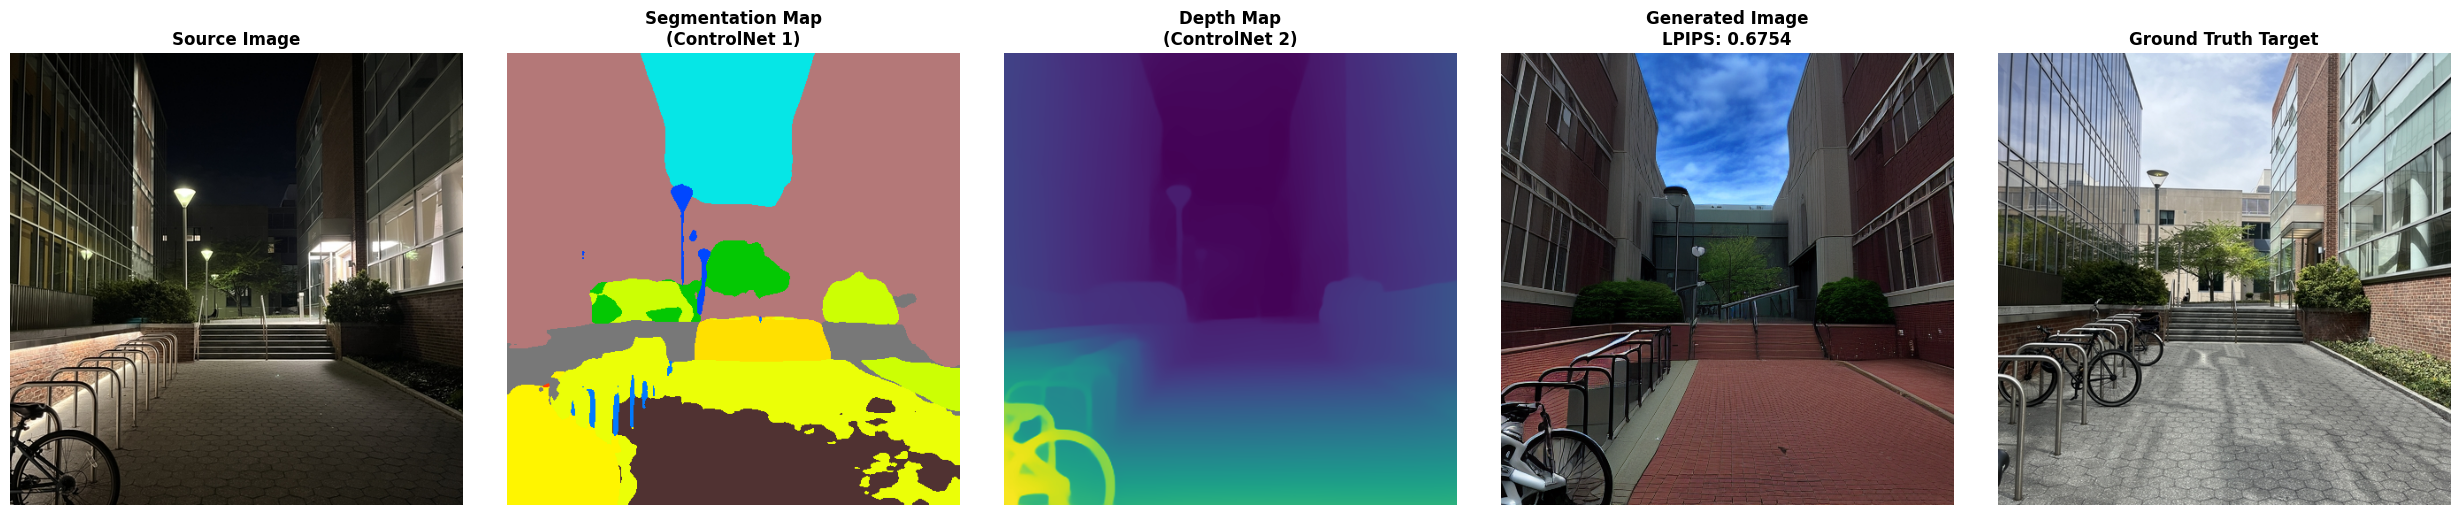

In [ ]:
# ========================================================================
# DUAL CONTROLNET (SEGMENTATION + DEPTH) INFERENCE
# ========================================================================

import torch
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("INFERENCE SETUP")
print("="*70)

# Check if inference_pipe already exists from Cell 28
if 'inference_pipe' not in globals():
    print("Loading models for inference...")

    # Reload fresh UNet
    from diffusers import UNet2DConditionModel
    from peft import PeftModel

    unet_inference = UNet2DConditionModel.from_pretrained(
        SD_PATH,
        subfolder="unet",
        torch_dtype=dtype,
        local_files_only=True
    ).to(device)

    # Load LoRA weights
    unet_inference = PeftModel.from_pretrained(
        unet_inference,
        os.path.join(LORA_OUTPUT_DIR, "lora_best"),
        local_files_only=True
    )

    # Build inference pipeline
    from diffusers import StableDiffusionControlNetImg2ImgPipeline, UniPCMultistepScheduler

    inference_pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
        SD_PATH,
        unet=unet_inference,
        vae=vae,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        controlnet=[controlnet_seg, controlnet_depth],
        torch_dtype=dtype,
        safety_checker=None,
        local_files_only=True
    ).to(device)

    inference_pipe.scheduler = UniPCMultistepScheduler.from_config(inference_pipe.scheduler.config)
    print("✓ Inference pipeline built")
else:
    print("✓ Using existing inference_pipe from Cell 28")

print("="*70)


# ========================================================================
# GENERATION FUNCTION
# ========================================================================

def generate_dual_controlnet(
    source_image,
    prompt,
    strength=0.8,
    num_inference_steps=30,
    guidance_scale=12.5,
    controlnet_conditioning_scale=[0.8, 0.6],  # [seg, depth]
    seed=42
):
    """
    Generate style transfer using Segmentation + Depth ControlNets + LoRA + img2img.
    """
    # Load image if path
    if isinstance(source_image, str):
        source_image = Image.open(source_image).convert("RGB")

    # Resize to 512x512
    source_image = source_image.resize((512, 512), Image.BILINEAR)

    print(f"\n{'='*60}")
    print("Generating style transfer...")
    print(f"{'='*60}")
    print(f"Prompt: {prompt[:60]}..." if len(prompt) > 60 else f"Prompt: {prompt}")
    print(f"Strength: {strength}")
    print(f"ControlNet scales: seg={controlnet_conditioning_scale[0]}, depth={controlnet_conditioning_scale[1]}")

    # Compute conditioning maps
    print("Computing segmentation map...")
    seg_map = compute_segmentation_map(source_image)

    print("Computing depth map...")
    depth_map = depthMaps(source_image)

    # Set seed
    generator = torch.Generator(device=device).manual_seed(seed)

    # Generate with img2img + dual ControlNet
    print("Generating image...")
    with torch.no_grad():
        output = inference_pipe(
            prompt=prompt,
            image=source_image,  # img2img base
            control_image=[seg_map, depth_map],  # dual control
            strength=strength,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            controlnet_conditioning_scale=controlnet_conditioning_scale,
            generator=generator,
        )

    generated_image = output.images[0]

    print("✓ Generation complete")
    print(f"{'='*60}\n")

    return {
        "generated_image": generated_image,
        "seg_map": seg_map,
        "depth_map": depth_map,
        "source_image": source_image
    }


# ========================================================================
# VISUALIZATION
# ========================================================================

def visualize_dual_controlnet_results(result, target_image=None, lpips_score=None):
    """Visualize dual ControlNet generation results."""
    num_images = 4 if target_image is None else 5
    fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))

    # Source
    axes[0].imshow(result['source_image'])
    axes[0].set_title("Source Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Segmentation
    axes[1].imshow(result['seg_map'])
    axes[1].set_title("Segmentation Map\n(ControlNet 1)", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Depth
    axes[2].imshow(result['depth_map'])
    axes[2].set_title("Depth Map\n(ControlNet 2)", fontsize=12, fontweight='bold')
    axes[2].axis('off')

    # Generated
    gen_title = "Generated Image"
    if lpips_score is not None:
        gen_title += f"\nLPIPS: {lpips_score:.4f}"

    axes[3].imshow(result['generated_image'])
    axes[3].set_title(gen_title, fontsize=12, fontweight='bold')
    axes[3].axis('off')

    # Target (if provided)
    if target_image is not None:
        axes[4].imshow(target_image)
        axes[4].set_title("Ground Truth Target", fontsize=12, fontweight='bold')
        axes[4].axis('off')

    plt.tight_layout()
    plt.show()


print("✓ Functions defined\n")


# ========================================================================
# INTERACTIVE INFERENCE
# ========================================================================

# Upload source image
print("Upload source image:")
uploaded = files.upload()
source_filename = list(uploaded.keys())[0]
source_path = f"/content/{source_filename}"

# Enter prompt
print("\nEnter target condition prompt:")
prompt = input("Prompt: ")

# Optional: Upload target image for LPIPS
print("\nDo you have a ground truth target image? (y/n)")
has_target = input().lower().strip() == 'y'

target_image = None
if has_target:
    print("\nUpload target (ground truth) image:")
    target_files = files.upload()
    target_filename = list(target_files.keys())[0]
    target_image = Image.open(f"/content/{target_filename}").convert("RGB").resize((512, 512))

# Optional: Tune parameters
print("\nUse default parameters? (y/n)")
use_defaults = input().lower().strip() == 'y'

strength = 1.8
seg_scale = 0.8
depth_scale = 0.6

if not use_defaults:
    print("\nimg2img strength (0.3-0.5, default 0.4):")
    strength_input = input("Strength: ")
    if strength_input:
        strength = float(strength_input)

    print("\nSegmentation ControlNet scale (0.6-1.0, default 0.8):")
    seg_input = input("Seg scale: ")
    if seg_input:
        seg_scale = float(seg_input)

    print("\nDepth ControlNet scale (0.4-0.8, default 0.6):")
    depth_input = input("Depth scale: ")
    if depth_input:
        depth_scale = float(depth_input)

print("\n" + "="*70)
print("STARTING INFERENCE")
print("="*70)

# Generate
result = generate_dual_controlnet(
    source_image=source_path,
    prompt=prompt,
    strength=strength,
    num_inference_steps=30,
    guidance_scale=7.5,
    controlnet_conditioning_scale=[seg_scale, depth_scale],
    seed=42
)

# Compute LPIPS if target provided
lpips_score = None
if target_image is not None:
    print("\nComputing LPIPS...")
    lpips_score = compute_lpips(result['generated_image'], target_image)
    print(f"LPIPS Score: {lpips_score:.4f}")

# Visualize
visualize_dual_controlnet_results(
    result,
    target_image=target_image,
    lpips_score=lpips_score
)